# Reaching Breakeven with CZNR

*Notebook 2 - Clifford Noise Reduction (CliNR)* showed that on a three-qubit circuit, the verification machinery of CliNR costs more error than it removes. This notebook implements the simulation and breakeven demonstration from [1, 2]. 

The benefit grows with circuit size, so here we move to a larger circuit and a specialised version of the protocol (also with the intention of running it on real hardware in the next notebook in this series!), and we reach breakeven. 

**Breakeven** is the regime where the noise-reduced implementation achieves about the same logical error rate as the direct implementation, despite running many more gates. The verification removes enough error to compensate for the error its own gates introduce.

The specialisation is **CZNR**, the form CliNR takes when the Clifford circuit consists only of controlled-Z gates [1, 2]. CZNR needs only $n$ ancilla qubits instead of the $2n$ of general CliNR, and the post-measurement correction has a simple closed form. This is the variant that the hardware experiment in *Notebook 4 - CZNR on IonQ Hardware* runs.

### What this notebook does

1. Builds the dynamic CZNR circuit for $C^2$ on ten qubits, with corrections applied in-circuit by feedforward.
2. Confirms correctness with a noiseless check.
3. Compares CZNR against the direct implementation at a fixed noise level, for two families of verification stabilizers and CliNR verification sequence length $r = 1,2,3$.
4. Sweeps the noise rate to show how the two implementations compare as noise grows.

All circuits are Clifford and simulated exactly with [Stim](https://github.com/quantumlib/Stim). As in *Notebook 2 - Clifford Noise Reduction (CliNR)*, we assume full dynamic-circuit capabilities; the post-processing variant for hardware without mid-circuit measurement and feedback capabilities is in *Notebook 4 - CZNR on IonQ Hardware*.

## The circuit

The Clifford we implement in the CZNR version is the all-pairs CZ circuit on $N=10$ qubits,

$$C = \prod_{1 \le i < j \le N} \mathrm{CZ}_{ij}.$$

A circuit of CZ gates on $n$ qubits is described by a graph $G$: the qubits are vertices, and there is an edge between two vertices exactly when a CZ gate acts on that pair. Applying the circuit to $|+\rangle^{\otimes n}$ produces the **graph state** of $G$.

CZNR injects the CZ circuit using this graph state as the resource. The injection works as follows. The resource graph state sits on a second register. A CNOT is applied from each resource qubit to the corresponding data qubit, and the data qubits are then measured. This teleports the data onto the resource register with the CZ circuit applied, up to a Pauli correction.

### State preparation and running $C^2$

In this protocol, we run $C^2$. Because every CZ is its own inverse, $C^2$ is the identity on every state, so the ideal output equals the input, making logical error detection easier. To make errors detectable, the input cannot be $|0\dots0\rangle$: the all-zeros state is a fixed point of every CZ gate. 

We therefore prepare a nontrivial input with a layer of random single-qubit Clifford gates $C_{\mathrm{prep}}|0\rangle$ and undo that layer at the end, making the ideal output the all-zeros bitstring and the logical error rate the fraction of accepted runs whose output is not all zeros.

## Setup

In [1]:
#%pip install stim numpy matplotlib --quiet

import stim
import numpy as np
import matplotlib.pyplot as plt

## Building blocks

### Input state preparation on the data qubits

To test the protocol on a non-trivial state we prepare the input with a random layer of single-qubit Clifford gates, $C_{\mathrm{prep}}$, drawn from Hadamard and phase gates. 

In [2]:
def make_Cprep(n, seed):
    """A random single-qubit Clifford layer as a list of per-qubit gate sequences,
    drawn from {H, S, S_DAG}. Prepares a non-trivial input state."""
    rng = np.random.default_rng(seed)
    # For each qubit draw 3 gates from a pool padded with two 'I's, then drop the 'I's:
    # this yields a random-length sequence (0-3 gates) of H/S/S_DAG per qubit.
    return [[g for g in rng.choice(['H', 'S', 'S_DAG', 'I', 'I'], size=3) if g != 'I']
            for _ in range(n)]

def apply_Cprep(c, ops, offset, inverse=False):
    """Apply the Cprep layer (or its inverse) to qubits offset..offset+n-1.
    The inverse reverses the gate order per qubit and swaps S with S_DAG."""
    for q, layer in enumerate(ops):
        sequence = layer[::-1] if inverse else layer  # inverse: apply the gates in reverse order
        for g in sequence:
            # inverse of H is H; inverse of S is S_DAG and vice versa.
            gate = {'H': 'H', 'S': 'S_DAG', 'S_DAG': 'S'}[g] if inverse else g
            c.append(gate, [offset + q])

### Verification stabilizers

Two families of stabilizers cover the gate-cost range, and both are used here:

- **Low-weight**: $Y_i Y_j$ for a pair of qubits. These need the fewest extra gates to measure.
- **High-weight**: $X_i \prod_{j \ne i} Z_j$. These need the most.

When more than one stabilizer is used, the low-weight checks are chosen on non-overlapping pairs and the high-weight checks on distinct centres.

In [3]:
def lowweight_stab(i, j, offset, n):
    """Low-weight stabilizer Y_i Y_j of the resource graph state, as a PauliString on
    the full 3n-qubit register (the resource lives at the given offset)."""
    p = stim.PauliString(3 * n)
    p[offset + i] = 2   # Y on qubit i
    p[offset + j] = 2   # Y on qubit j
    return p

def highweight_stab(i, offset, n):
    """High-weight stabilizer X_i * product_{j != i} Z_j of the resource graph state."""
    p = stim.PauliString(3 * n)
    p[offset + i] = 1          # X on qubit i
    for j in range(n):
        if j != i:
            p[offset + j] = 3  # Z on every other qubit
    return p

def shift_to_res2(stab, n):
    """Move a stabilizer defined on resource 1 onto resource 2 (shift indices by n).
    Notebook 4 uses the same helper."""
    xs, zs = stab.to_numpy(); p = stim.PauliString(3 * n)
    for q in range(len(xs)):
        if xs[q] or zs[q]:
            p[q + n] = 2 if (xs[q] and zs[q]) else (1 if xs[q] else 3)
    return p

### The noise model

We use the same noise model introduced in Notebook 2, a simple depolarizing model with two-qubit gate error rate $p$, single-qubit gate and measurement error rates at $p/10$. Resets and feedforward gates carry no gate noise. Idle noise is omitted here for clarity.

In [4]:
def add_noise(circuit, p):
    """Return a copy of circuit with depolarizing noise after each operation.
    Two-qubit gates: rate p. Single-qubit: rate p/10. Measurements: flip with p/10.
    Resets and feedforward are noiseless; idle noise is omitted. p = 0 is unchanged."""
    if p == 0:
        return circuit.copy()                # no noise requested: hand back an untouched copy
    p1 = p / 10.0                            # single-qubit / measurement rate, ten times gentler
    one_qubit = {'H', 'S', 'S_DAG', 'X', 'Y', 'Z'}
    two_qubit = {'CX', 'CY', 'CZ', 'SWAP'}
    out = stim.Circuit()                     # rebuild the circuit instruction by instruction
    for inst in circuit:
        name = inst.name
        targets = inst.targets_copy()
        # A feedforward (classically controlled) gate carries a measurement-record target;
        # detect it so those gates can be left noiseless below.
        is_feedforward = any(t.is_measurement_record_target for t in targets)
        # Keep only the qubit operands, dropping any measurement-record target.
        qs = [t.value for t in targets if not t.is_measurement_record_target]
        if name in ('M', 'MZ'):
            # Readout error: flip the qubit just before measuring it (same as flipping the bit).
            for q in qs: out.append('X_ERROR', [q], p1)
            out.append(inst)
        elif name == 'R' or is_feedforward:
            out.append(inst)                 # resets and feedforward corrections carry no gate noise
        elif name in one_qubit:
            out.append(inst)
            for q in qs: out.append('DEPOLARIZE1', [q], p1)      # depolarize each acted-on qubit
        elif name in two_qubit:
            out.append(inst)
            # Two-qubit targets come in (control, target) pairs; tag each pair with 2-qubit noise.
            for k in range(0, len(qs), 2):
                out.append('DEPOLARIZE2', [qs[k], qs[k + 1]], p)
        else:
            out.append(inst)                 # anything else passes through untouched
    return out

## The dynamic CZNR circuit for $C^2$

We implement $C^2$ with CZNR using three registers of $n$ qubits each, plus one ancilla qubit for the stabilizer readout:

- the **input register** holds $C_{\mathrm{prep}}|0\rangle$,
- two **resource registers** each hold a copy of the graph state $C|+\rangle^{\otimes n}$,
- one **ancilla qubit** performs the verification measurements, reset between checks.

The flow is:

1. Prepare the input on the input register and a graph state on each resource register.
2. Verify the first resource, then inject $C$ onto the input by consuming it. The result moves onto the first resource register.
3. Verify the second resource, then inject $C$ again, consuming the second resource. The result, now $C^2$ applied to the input, moves onto the second resource register.
4. Undo the input preparation on that register and measure.

Each injection applies the correction $Q$ in-circuit, conditioned on the teleportation measurements.

### The Pauli correction

For a general Clifford circuit $C$, the teleportation Pauli correction conditioned on measuring qubit $i$ in state $|1\rangle$ is the operator

$$C^\dagger X_i C,$$

applied to the resource register carrying the output. For CZNR the circuit $C$ is the all-pairs CZ circuit, and the correction takes a particularly simple closed form. Because each $\mathrm{CZ}_{ij}$ conjugates $X_i$ to $X_i Z_j$, and the all-pairs circuit is self-inverse ($C = C^\dagger$), we get

$$C^\dagger X_i C = X_i \prod_{j \in N(i)} Z_j,$$

where $N(i)$ is the set of graph neighbours of vertex $i$. For the all-pairs circuit every vertex is connected to every other, so $N(i) = \{0,\ldots,n-1\} \setminus \{i\}$. In the circuit this means: if the measurement of qubit $i$ returns one, apply a $\mathrm{CX}$ on the resource copy of qubit $i$ and a $\mathrm{CZ}$ on every other resource qubit. 

In [5]:
# Number of data qubits.
N = 10

# Helper functions for building the graph states

def C_on(offset, n):
    """The all-pairs controlled-Z circuit on qubits offset..offset+n-1: a CZ between
    every pair. Applied to |+>^n it prepares the fully connected graph state."""
    c = stim.Circuit()
    for i in range(n):
        for j in range(i + 1, n):
            c.append('CZ', [offset + i, offset + j])
    return c

def neighbors(i, n):
    """Neighbours of vertex i in the fully connected graph: every other vertex.
    This is the set N(i) that appears in the correction Q."""
    return [j for j in range(n) if j != i]

In [6]:
def build_cznr_csquared(n, Cprep, stabilizers, ancilla):
    """Build the C-squared CZNR circuit with the in-circuit Q correction.

    Registers: input = 0..n-1, resource1 = n..2n-1, resource2 = 2n..3n-1.
    `stabilizers` are checks on resource1; the same operators shifted by n are checked
    on resource2. `ancilla` is reused for all checks.
    Returns (circuit, number_of_verification_measurements)."""
    R_in, R_res1, R_res2 = 0, n, 2 * n
    c = stim.Circuit()

    # 1. Input state, and a graph state C|+>^n on each resource register.
    apply_Cprep(c, Cprep, R_in)
    for i in range(n): c.append('H', [R_res1 + i])
    c += C_on(R_res1, n)
    for i in range(n): c.append('H', [R_res2 + i])
    c += C_on(R_res2, n)

    def verify(stab):
        """Measure one stabilizer with the shared ancilla, then reset it."""
        c.append('R', [ancilla]); c.append('H', [ancilla])
        xs, zs = stab.to_numpy()
        for q in range(len(xs)):
            if   xs[q] and zs[q]: c.append('CY', [ancilla, q])
            elif xs[q]:           c.append('CX', [ancilla, q])
            elif zs[q]:           c.append('CZ', [ancilla, q])
        c.append('H', [ancilla]); c.append('M', [ancilla]); c.append('R', [ancilla])

    def inject_and_correct(resource, target):
        """Graph-state injection of C from `resource` onto `target`, with the Q
        correction applied in-circuit. The measured register is `target`; the output
        stays on `resource`."""
        for i in range(n): c.append('CX', [resource + i, target + i])   # injection CNOTs
        for i in range(n): c.append('M', [target + i])                  # measure data
        # The n target measurements are the most recent; target+i sits at rec[-(n-i)].
        for i in range(n):
            rec = stim.target_rec(-(n - i))
            c.append('CX', [rec, resource + i])           # X_i correction (qubit i flips)
            for j in neighbors(i, n):
                c.append('CZ', [rec, resource + j])       # Z_j correction for each neighbour
                                                            # (because CZ conjugates X_i to X_i * prod_j Z_j)

    # 2. Verify resource1, inject C onto the input (output now on resource1).
    for s in stabilizers: verify(s)
    inject_and_correct(resource=R_res1, target=R_in)

    # 3. The same stabilizers are measured on resource2, shifted onto its qubits with
    #    shift_to_res2 (the same helper Notebook 4 uses). This keeps the two checks
    #    symmetric, so errors in either resource register are equally likely to be caught.
    for s in stabilizers: verify(shift_to_res2(s, n))
    inject_and_correct(resource=R_res2, target=R_res1)

    # 4. Undo the input preparation on resource2 and measure it.
    apply_Cprep(c, Cprep, R_res2, inverse=True)
    for i in range(n): c.append('M', [R_res2 + i])
    return c, 2 * len(stabilizers)

### Drawn on three qubits

Like the hardware notebook, we draw the circuit at three qubits per register so the wiring stays legible; the full $n = 10$ version has the same shape, just wider. Because this is the *dynamic* implementation, the diagram shows the in-circuit stabilizer measurements and the feedforward $Q$ corrections — exactly the operations Notebook 4 removes from the circuit by deferring them to classical post-processing.

In [7]:
# Draw the dynamic CZNR circuit at three qubits per register, with one low-weight check per
# resource, so the structure stays legible. The n = 10 circuit used below has the same shape.
n_draw = 3
Cprep_draw = make_Cprep(n_draw, seed=5)
stabs_draw = [lowweight_stab(0, 1, n_draw, n_draw)]   # one Y_0 Y_1 check on resource 1
demo_circuit, _ = build_cznr_csquared(n_draw, Cprep_draw, stabs_draw, ancilla=3 * n_draw)
# White panel keeps the black gate glyphs legible on any notebook theme
# (stim draws them black-on-transparent, which vanishes on a dark background).
from IPython.display import HTML
HTML(f'<div style="background:white; padding:10px; overflow-x:auto">'
     f'{demo_circuit.diagram("timeline-svg")}</div>')

### Running and scoring

Two helper functions run the circuits and report the logical error rate.

For CZNR, we read the measurement record in order: the verification outcomes, then the two teleportation rounds, then the final output. A shot is accepted only if every verification outcome is trivial; rejected shots correspond to detected faults and would be repeated on hardware. Among accepted shots, the logical error rate is the fraction whose final output is not all zeros.

For the direct implementation, we simply run $C^2$ on the prepared input, undo the preparation, and measure.

In [8]:
def run_cznr(n, Cprep, stabilizers, p, shots=60000, seed=1):
    """Run the CZNR C-squared circuit. Return (logical_error_rate, acceptance_rate).
    A shot is accepted only if every verification measured zero; among accepted shots,
    a logical error is an output that is not all zeros."""
    ancilla = 3 * n
    circuit, n_verify = build_cznr_csquared(n, Cprep, stabilizers, ancilla)
    samples = add_noise(circuit, p).compile_sampler(seed=seed).sample(shots)
    r = len(stabilizers)
    # Measurement record order matches the circuit construction in build_cznr_csquared:
    # [verify1: r outcomes] [inject1 data (target reg): n] [verify2: r] [inject2 data: n] [output: n]
    # Offsets into each row are computed incrementally with idx.
    n_accept = n_zero = 0
    for row in samples:
        idx = 0
        verify1 = row[idx:idx + r]; idx += r
        idx += n                          # skip first injection measurements
        verify2 = row[idx:idx + r]; idx += r
        idx += n                          # skip second injection measurements
        output = row[idx:idx + n]; idx += n
        if any(int(b) for b in verify1) or any(int(b) for b in verify2):
            continue                      # detected fault: discard
        n_accept += 1
        if not any(int(b) for b in output):
            n_zero += 1
    logical_error = 1 - n_zero / n_accept if n_accept else 1.0
    return logical_error, n_accept / shots

def run_direct(n, Cprep, p, shots=60000, seed=2):
    """Run C squared directly on the prepared input. Return the logical error rate."""
    c = stim.Circuit()
    apply_Cprep(c, Cprep, 0)
    c += C_on(0, n); c += C_on(0, n)
    apply_Cprep(c, Cprep, 0, inverse=True)
    for i in range(n): c.append('M', [i])
    samples = add_noise(c, p).compile_sampler(seed=seed).sample(shots)
    n_zero = sum(1 for row in samples if not any(int(b) for b in row[:n]))
    return 1 - n_zero / shots

## Noiseless check

Before measuring any benefit, we confirm the protocol is correct. With no noise, both the direct and CZNR implementations of $C^2$ must return the all-zeros bitstring on every accepted shot, giving a logical error rate of exactly zero. 

In [9]:
# Fixed input layer for all runs in this notebook.
Cprep = make_Cprep(N, seed=5)

# A single low-weight check suffices for the noiseless correctness test.
check_stabs = [lowweight_stab(0, 1, N, N)]

direct0 = run_direct(N, Cprep, p=0.0, shots=4000)
cznr0, accept0 = run_cznr(N, Cprep, check_stabs, p=0.0, shots=4000)

print(f'Noiseless direct logical error: {direct0:.4f}')
print(f'Noiseless CZNR logical error:   {cznr0:.4f}   (acceptance {accept0:.3f})')

assert direct0 == 0.0 and cznr0 == 0.0, 'Noiseless check failed: an implementation is incorrect.'
print('\nNoiseless check passed: both return all zeros on every shot.')

Noiseless direct logical error: 0.0000
Noiseless CZNR logical error:   0.0000   (acceptance 1.000)

Noiseless check passed: both return all zeros on every shot.


## Direct versus CZNR at a fixed noise level

We now compare the two implementations at a two-qubit noise rate of $p = 1e-3$, for both stabilizer families and verification sequence lengths $r = 1,2,3$. The direct implementation is the baseline. CZNR adds gates but removes faults; the question is the net effect on the logical error rate, and whether longer verification keeps it flat (the signature of breakeven) or lowers it (below breakeven).

In [10]:
P_PHYSICAL = 1e-3   # two-qubit depolarizing rate
SHOTS = 60000

direct_error = run_direct(N, Cprep, P_PHYSICAL, shots=SHOTS, seed=2)
print(f'Direct logical error rate at p = {P_PHYSICAL:.0e}: {direct_error:.5f}\n')

rng = np.random.default_rng(11)
results = {}
for family in ['low-weight', 'high-weight']:
    for r in [1, 2, 3]:
        if family == 'low-weight':
            # r non-overlapping Y_i Y_j checks
            pairs, used = [], set()
            while len(pairs) < r:
                i, j = rng.choice(N, size=2, replace=False)
                if i in used or j in used: continue
                used |= {int(i), int(j)}; pairs.append((int(i), int(j)))
            stabs = [lowweight_stab(i, j, N, N) for i, j in pairs]
        else:
            centres = list(rng.choice(N, size=r, replace=False))
            stabs = [highweight_stab(int(i), N, N) for i in centres]
        error, accept = run_cznr(N, Cprep, stabs, P_PHYSICAL, shots=SHOTS, seed=3)
        results[(family, r)] = (error, accept)
        print(f'  {family:11}, r={r}: logical error {error:.5f}, acceptance {accept:.3f}')

Direct logical error rate at p = 1e-03: 0.07428

  low-weight , r=1: logical error 0.07355, acceptance 0.980
  low-weight , r=2: logical error 0.06151, acceptance 0.961
  low-weight , r=3: logical error 0.05538, acceptance 0.946
  high-weight, r=1: logical error 0.05265, acceptance 0.943
  high-weight, r=2: logical error 0.04190, acceptance 0.919
  high-weight, r=3: logical error 0.04521, acceptance 0.898


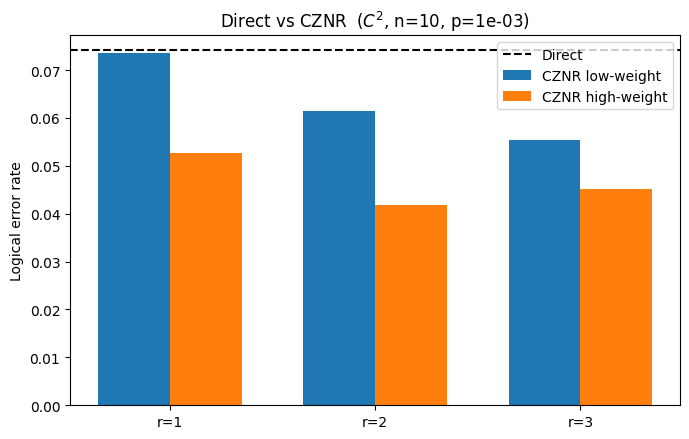

In [11]:
# Bar chart: direct baseline against CZNR for each family and verification length.
fig, ax = plt.subplots(figsize=(7, 4.5))
rs = [1, 2, 3]                                        # verification lengths to show
x = np.arange(len(rs)); width = 0.35                  # bar positions and width
# Pull the logical error (first element of each stored result tuple) for each family.
low = [results[('low-weight', r)][0] for r in rs]
high = [results[('high-weight', r)][0] for r in rs]
ax.bar(x - width/2, low, width, label='CZNR low-weight')     # low-weight bars, left of centre
ax.bar(x + width/2, high, width, label='CZNR high-weight')   # high-weight bars, right of centre
ax.axhline(direct_error, color='black', linestyle='--', label='Direct')   # baseline reference line
ax.set_xticks(x); ax.set_xticklabels([f'r={r}' for r in rs])
ax.set_ylabel('Logical error rate')
ax.set_title(f'Direct vs CZNR  ($C^2$, n={N}, p={P_PHYSICAL:.0e})')
ax.legend()
plt.tight_layout(); plt.show()

## Sweeping the noise rate

A single noise value gives one snapshot. Sweeping the physical error rate shows how the direct and CZNR implementations compare across a range of conditions. We fix a high-weight verification sequence of length two, which performed well in the fixed-noise comparison above, and vary $p$.

p = 3.0e-04:  direct 0.02205,  CZNR 0.01318
p = 1.0e-03:  direct 0.07428,  CZNR 0.04092
p = 3.0e-03:  direct 0.20248,  CZNR 0.12189
p = 1.0e-02:  direct 0.52398,  CZNR 0.37280


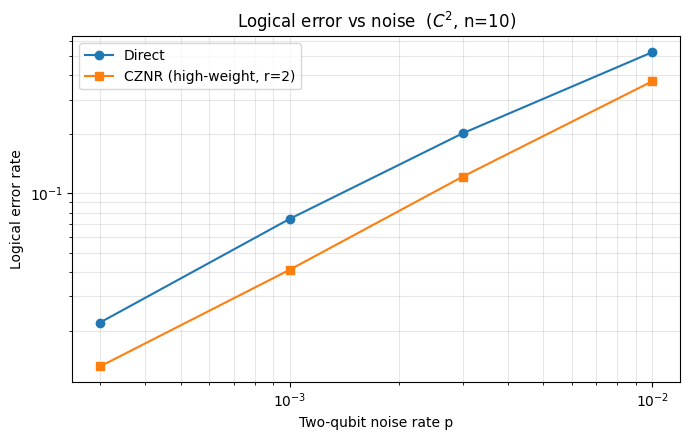

In [12]:
# Sweep the two-qubit noise rate over nearly two orders of magnitude.
noise_levels = [3e-4, 1e-3, 3e-3, 1e-2]
# Fixed high-weight verification of length two (centres 0 and 5), the best performer above.
sweep_stabs = [highweight_stab(0, N, N), highweight_stab(5, N, N)]

# Logical error of each implementation at every noise level.
direct_curve, cznr_curve = [], []
for p in noise_levels:
    d = run_direct(N, Cprep, p, shots=60000, seed=2)                 # baseline
    c, _ = run_cznr(N, Cprep, sweep_stabs, p, shots=60000, seed=3)   # CZNR (accepted shots only)
    direct_curve.append(d); cznr_curve.append(c)
    print(f'p = {p:.1e}:  direct {d:.5f},  CZNR {c:.5f}')

# Log-log plot: both the noise rate and the logical error span orders of magnitude.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(noise_levels, direct_curve, 'o-', label='Direct')
ax.loglog(noise_levels, cznr_curve, 's-', label='CZNR (high-weight, r=2)')
ax.set_xlabel('Two-qubit noise rate p')
ax.set_ylabel('Logical error rate')
ax.set_title(f'Logical error vs noise  ($C^2$, n={N})')
ax.legend(); ax.grid(True, which='both', alpha=0.3)                  # grid on major and minor ticks
plt.tight_layout(); plt.show()

## What we see

At ten qubits the picture is different from the three-qubit case. The CZNR implementation reaches about the same logical error rate as the direct implementation, and the high-weight verification brings it below. 

Increasing the verification length does not raise the error, which is the signature of breakeven: the noise the verification adds is balanced by the noise it removes. The acceptance rate falls as the verification gets longer or the noise grows, since more runs trip a check and are discarded. 

This is the same comparison the hardware experiment makes. The next notebook in this tutorial series, *Notebook 4 - CZNR on IonQ Hardware*, runs exactly this CZNR circuit on a trapped-ion device, where mid-circuit measurement is not available, so the corrections and restarts are handled in classical post-processing instead of in-circuit feedforward. 

## References

[1] N. Delfosse and E. Tham, "Clifford Noise Reduction," arXiv:2407.06583 (2024).

[2] E. Tham and N. Delfosse, "Optimized Clifford Noise Reduction: Theory, Simulations and Experiments," *Quantum* **9**, 1829 (2025). [arXiv:2504.13356](https://arxiv.org/abs/2504.13356)